STEP 1 — Mount Drive & Set Folder

In [ ]:
!pip install rdkit
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 51.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 2 — Path to WS22 Folder

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Project/WS22Dataset/7032334/"
files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith(".npz")])
print(files)

['ws22_acrolein.npz', 'ws22_alanine.npz', 'ws22_dmabn.npz', 'ws22_nitrophenol.npz', 'ws22_o-hbdi.npz', 'ws22_sma.npz', 'ws22_thymine.npz', 'ws22_toluene.npz', 'ws22_urea.npz', 'ws22_urocanic.npz']


STEP 3 — Bond Reconstruction Function

In [ ]:
from rdkit.Chem import rdchem
import numpy as np

COVALENT_RADII = {
    1: 0.31,   # H
    6: 0.76,   # C
    7: 0.71,   # N
    8: 0.66,
    16: 1.05
}

def build_molecule_with_bonds(Z, R, scale=1.15):
    mol = Chem.RWMol()
    conf = Chem.Conformer(len(Z))

    for i, atomic_num in enumerate(Z):
        atom = Chem.Atom(int(atomic_num))
        mol_idx = mol.AddAtom(atom)
        conf.SetAtomPosition(mol_idx, tuple(R[i]))

    mol.AddConformer(conf)

    # Distance-based bond assignment
    for i in range(len(Z)):
        for j in range(i+1, len(Z)):
            ri = COVALENT_RADII.get(int(Z[i]), 0.77)
            rj = COVALENT_RADII.get(int(Z[j]), 0.77)
            threshold = scale * (ri + rj)

            dist = np.linalg.norm(R[i] - R[j])

            if dist < threshold:
                mol.AddBond(i, j, rdchem.BondType.SINGLE)

    mol = mol.GetMol()
    Chem.SanitizeMol(mol)
    AllChem.Compute2DCoords(mol)
    return mol

STEP 4 — Load ONE Representative Conformation from Each Molecule

In [ ]:
molecule_list = []
molecule_names = []

for file in files:
    data = np.load(os.path.join(DATA_PATH, file), allow_pickle=True)

    Z = data["Z"]
    R = data["R"][0]  # First conformation only

    mol = build_molecule_with_bonds(Z, R)
    molecule_list.append(mol)

    name = file.replace("ws22_", "").replace(".npz", "")
    molecule_names.append(name)

print("Loaded molecules:", molecule_names)

Loaded molecules: ['acrolein', 'alanine', 'dmabn', 'nitrophenol', 'o-hbdi', 'sma', 'thymine', 'toluene', 'urea', 'urocanic']


STEP 5 — Display All 10 in One Grid

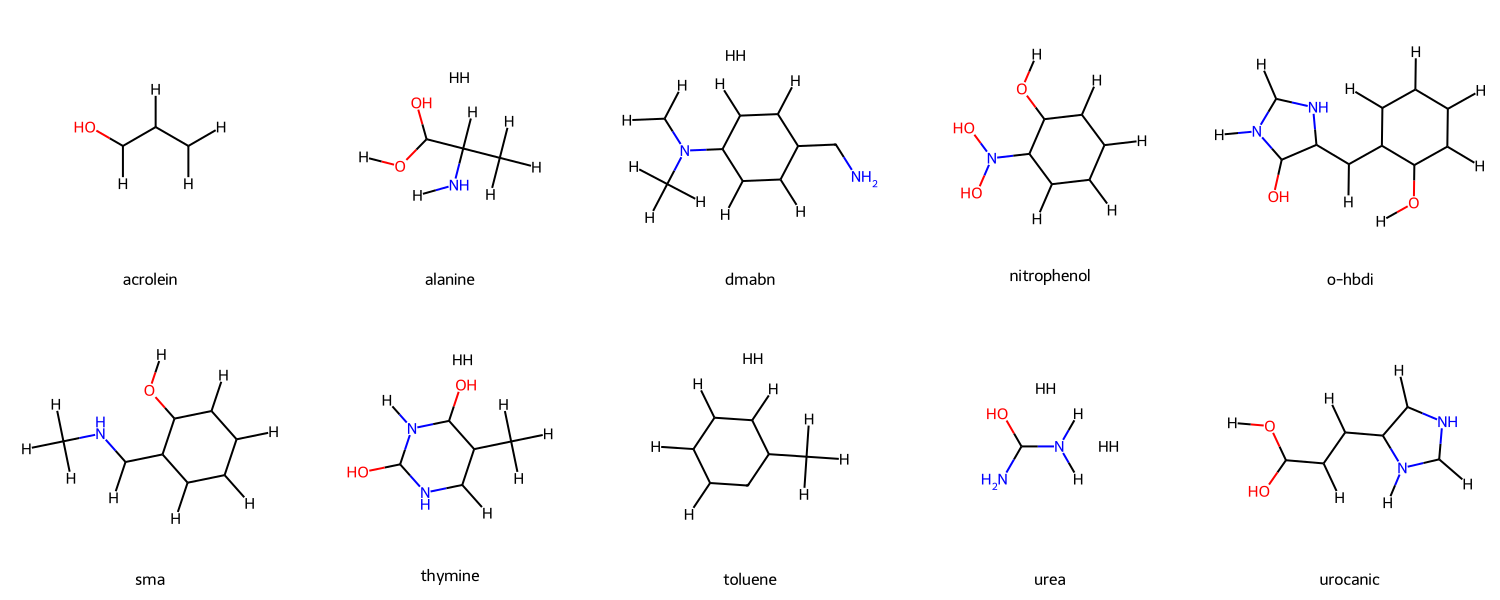

In [ ]:
img = Draw.MolsToGridImage(
    molecule_list,
    molsPerRow=5,
    subImgSize=(300,300),
    legends=molecule_names
)

img

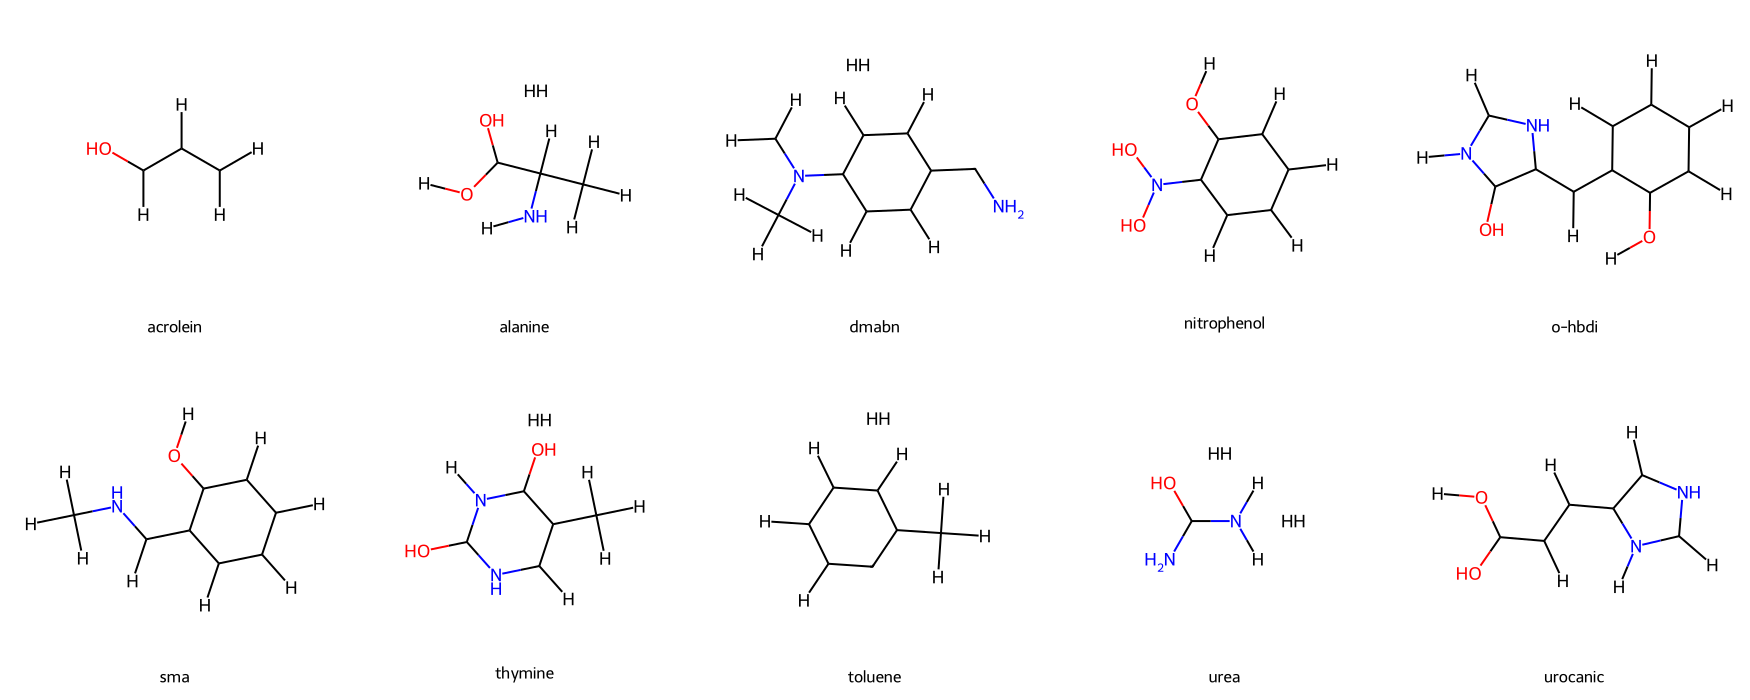

In [ ]:
img = Draw.MolsToGridImage(
    molecule_list,
    molsPerRow=5,
    subImgSize=(350,350),
    legends=molecule_names
)

img

In [ ]:
!pip install py3Dmol

In [ ]:
import py3Dmol

grid_cols = 5
grid_rows = 2

viewer = py3Dmol.view(width=1000, height=600, viewergrid=(grid_rows, grid_cols))
viewer.setBackgroundColor('white')

index = 0

for row in range(grid_rows):
    for col in range(grid_cols):
        mol = molecule_list[index]
        name = molecule_names[index]

        mb = Chem.MolToMolBlock(mol)

        viewer.addModel(mb, 'mol', viewer=(row, col))
        viewer.setStyle({'stick':{}}, viewer=(row, col))
        viewer.zoomTo(viewer=(row, col))

        # 🔹 Add molecule name label
        viewer.addLabel(
            name,
            {
                'position': {'x': 0, 'y': 0, 'z': 0},
                'backgroundColor': 'white',
                'fontColor': 'black',
                'fontSize': 14,
                'showBackground': True
            },
            viewer=(row, col)
        )

        index += 1

viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
import py3Dmol

viewer = py3Dmol.view(width=900, height=600)
viewer.setBackgroundColor('white')

grid_cols = 5
grid_rows = 2

viewer = py3Dmol.view(width=900, height=600, viewergrid=(grid_rows, grid_cols))

index = 0

for row in range(grid_rows):
    for col in range(grid_cols):
        mol = molecule_list[index]
        mb = Chem.MolToMolBlock(mol)

        viewer.addModel(mb, 'mol', viewer=(row, col))
        viewer.setStyle({'stick':{}}, viewer=(row, col))
        viewer.zoomTo(viewer=(row, col))

        index += 1

viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Produces For each molecule:**

*   PCA conformational distribution
*   Energy-colored cloud
*   2D structure overlay
*   Clean multi-panel layout

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import rdchem
from PIL import Image

In [ ]:
COVALENT_RADII = {1:0.31,6:0.76,7:0.71,8:0.66,16:1.05}

def build_molecule_with_bonds(Z, R, scale=1.15):
    mol = Chem.RWMol()
    conf = Chem.Conformer(len(Z))

    for i, atomic_num in enumerate(Z):
        atom = Chem.Atom(int(atomic_num))
        mol_idx = mol.AddAtom(atom)
        conf.SetAtomPosition(mol_idx, tuple(R[i]))

    mol.AddConformer(conf)

    for i in range(len(Z)):
        for j in range(i+1, len(Z)):
            ri = COVALENT_RADII.get(int(Z[i]), 0.77)
            rj = COVALENT_RADII.get(int(Z[j]), 0.77)
            threshold = scale * (ri + rj)
            dist = np.linalg.norm(R[i] - R[j])
            if dist < threshold:
                mol.AddBond(i, j, rdchem.BondType.SINGLE)

    mol = mol.GetMol()
    Chem.SanitizeMol(mol)
    AllChem.Compute2DCoords(mol)
    return mol

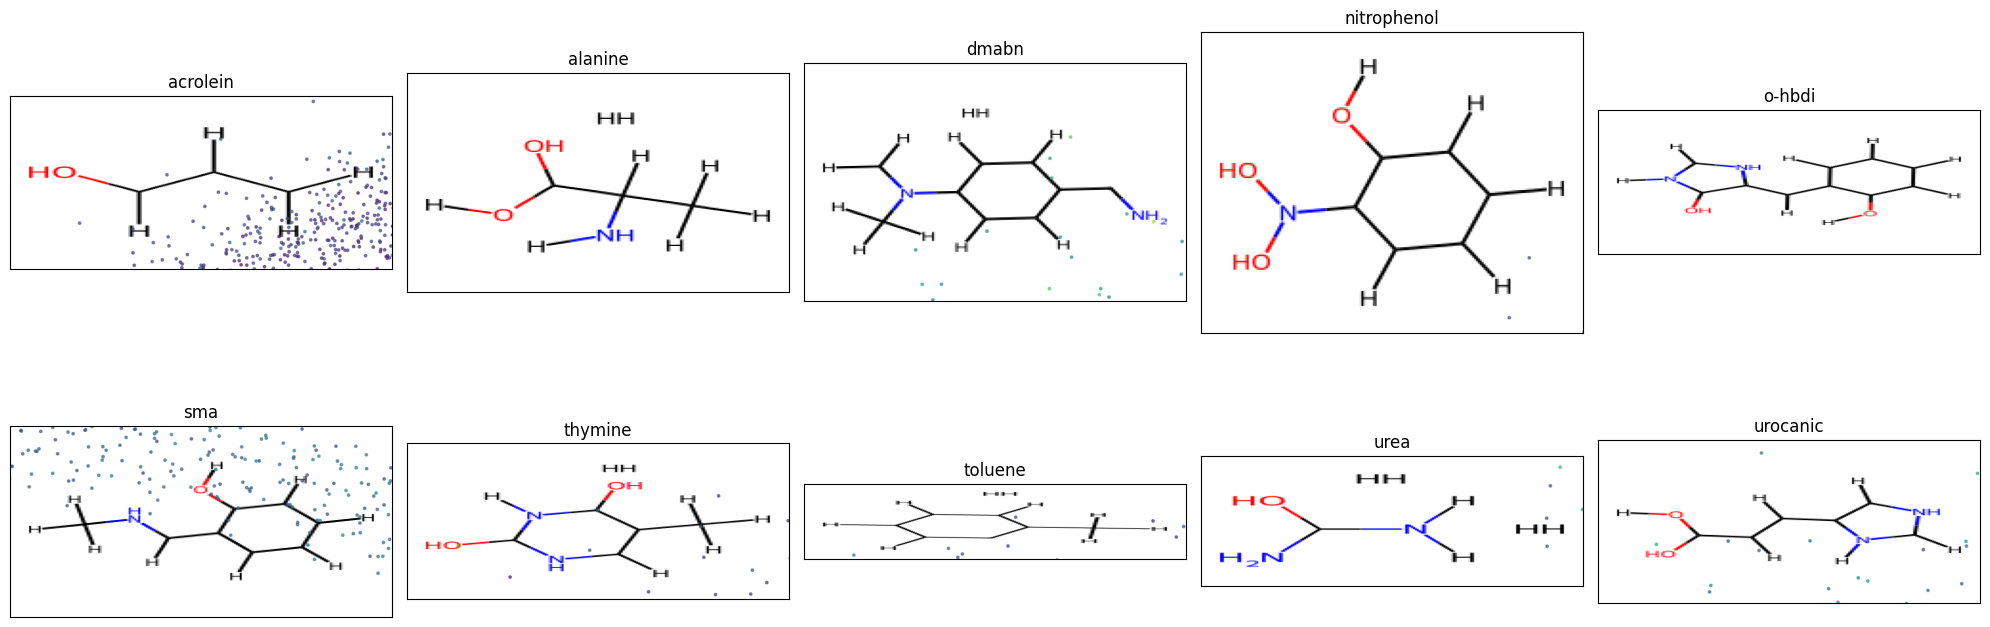

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Project/WS22Dataset/7032334/"
files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith(".npz")])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, file in enumerate(files):
    data = np.load(os.path.join(DATA_PATH, file), allow_pickle=True)

    Z = data["Z"]
    R = data["R"]
    E = data["E"].flatten()

    # Sample to avoid overload
    R_sample = R[:5000]
    E_sample = E[:5000]

    # Flatten coordinates for PCA
    coords_flat = R_sample.reshape(len(R_sample), -1)

    pca = PCA(n_components=2)
    proj = pca.fit_transform(coords_flat)

    ax = axes[idx]

    # Scatter PCA
    scatter = ax.scatter(
        proj[:,0],
        proj[:,1],
        c=E_sample,
        s=3,
        cmap="viridis",
        alpha=0.6
    )

    # Build representative molecule
    mol = build_molecule_with_bonds(Z, R[0])
    img = Draw.MolToImage(mol, size=(200,200))

    # Convert RDKit image to array
    img = np.array(img)

    # Overlay structure
    ax.imshow(img, extent=[
        proj[:,0].min()*0.6,
        proj[:,0].min()*0.2,
        proj[:,1].max()*0.6,
        proj[:,1].max()*0.9
    ])

    ax.set_title(file.replace("ws22_","").replace(".npz",""))
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()